#Importing The Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Loading The Dataset

In [2]:
df = pd.read_csv('/content/hotel_booking.csv')

In [3]:
df.tail().T

,119385,119386,119387,119388,119389
hotel,City Hotel,City Hotel,City Hotel,City Hotel,City Hotel
is_canceled,0,0,0,0,0
lead_time,23,102,34,109,205
arrival_date_year,2017,2017,2017,2017,2017
arrival_date_month,August,August,August,August,August
arrival_date_week_number,35,35,35,35,35
arrival_date_day_of_month,30,31,31,31,29
stays_in_weekend_nights,2,2,2,2,2
stays_in_week_nights,5,5,5,5,7
adults,2,3,2,2,2


# Basic Analysis
1. Getting The Information About The Dataset.

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 36 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

**Observations**
- From the above analysis, it is cleared that dataset contains 35 attributes containing different types of different datatypes.
- From the dataset, it is cleared that some attributes have many missing values that we need to take care of for better analysis.

2. Finding The Missing Values

In [5]:
df.isnull().sum()

,0
hotel,0
is_canceled,0
lead_time,0
arrival_date_year,0
arrival_date_month,0
arrival_date_week_number,0
arrival_date_day_of_month,0
stays_in_weekend_nights,0
stays_in_week_nights,0
adults,0


**Observations**
- As expected, some attributes contains significant number of missing values.
- So, we cannot just drop the missing values as it removes large portion of the dataset which can be useful for analysis. We need to impute this missing value with the imputation techniques

Filling The Missing Values

In [6]:
df['country'].fillna(df['country'].mode()[0], inplace=True) # Here we are using the mode imputation technique to fill the missing values



**Filling The Agent & Children Missing Values**
- Since agent and children have the values of type float we are just filling it with the 0 for better analysis

In [7]:
df['agent'] = df['agent'].fillna(0)
df['children'].fillna(0, inplace=True)


**Dropping The Company Column**
- We are dropping the company columns because it only have approximately 6% of values. So we cannot impute the values also as it creates noise in the data. Better to drop it.

In [8]:
df.drop('company', axis=1, inplace=True)

Checking The Missing Values again.

In [9]:
df.isnull().sum()

,0
hotel,0
is_canceled,0
lead_time,0
arrival_date_year,0
arrival_date_month,0
arrival_date_week_number,0
arrival_date_day_of_month,0
stays_in_weekend_nights,0
stays_in_week_nights,0
adults,0


3. Checking For The Duplicates

In [10]:
duplicate_count = df.duplicated().sum()
print(f"Total Duplicates: {duplicate_count}")

Total Duplicates: 0


# Exploratory Data Analysis
1. Checking The Distribution of Cancellation and Non Cancellation

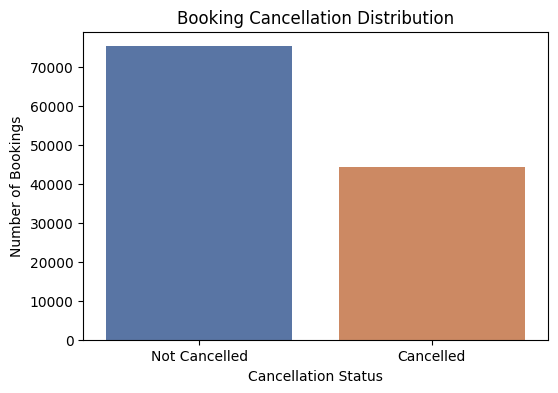

In [11]:
plt.figure(figsize=(6,4))
sns.countplot(x='is_canceled', data=df, palette='deep')

plt.title('Booking Cancellation Distribution')
plt.xlabel('Cancellation Status')
plt.ylabel('Number of Bookings')
plt.xticks([0,1], ['Not Cancelled', 'Cancelled'])

plt.show()

**Observations**
- From the above chart it is cleared that the dataset contains more non-cancelled bookings than cancelled bookings.
- But the cancelled bookings are also in the significant amount so we need to take a note of this also.

2. Checking The Percentage of Cancellations & Non Cancellation Bookings.

In [12]:
cancellation_percentage = (df['is_canceled'].value_counts(normalize=True) * 100).round(2)

print(f"Not Cancelled: {cancellation_percentage[0]}%")
print(f"Cancelled: {cancellation_percentage[1]}%")

Not Cancelled: 62.96%
Cancelled: 37.04%


3. Checking The Number of Bookings by hotel type

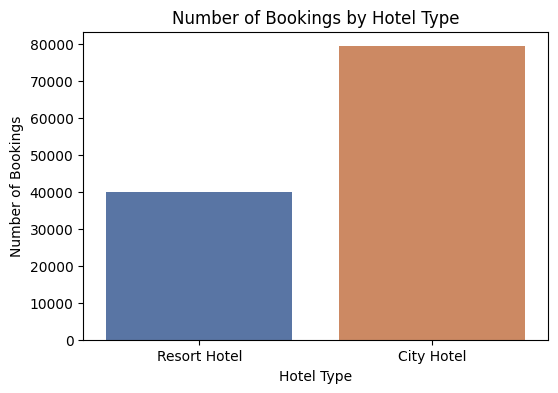

In [13]:
plt.figure(figsize=(6,4))

sns.countplot(x='hotel', data=df, palette= 'deep')

plt.title('Number of Bookings by Hotel Type')
plt.xlabel('Hotel Type')
plt.ylabel('Number of Bookings')

plt.show()

**Observations**
- From the above it is cleared that **City Hotel** got **more bookings** than the **Resort Hotel**.

4. Checking The Cancellation By The Hotel Type

Text(0, 0.5, 'Cancellation Rate (%)')

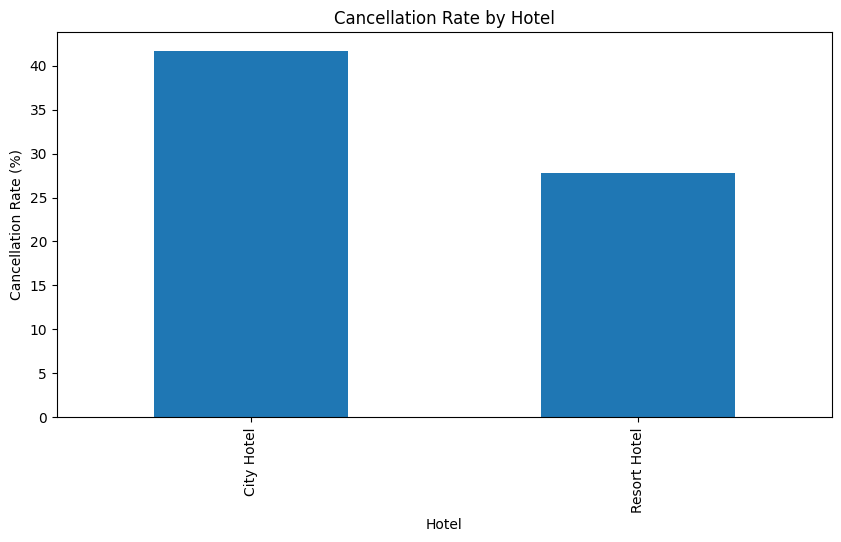

In [14]:
cancel_rate = df.groupby('hotel')['is_canceled'].mean() * 100

plt.figure(figsize = (10,5))
cancel_rate.plot(kind = 'bar')
plt.title('Cancellation Rate by Hotel')
plt.xlabel('Hotel')
plt.ylabel('Cancellation Rate (%)')

**Observations**
- From the above chart, it is cleared that **City Hotel** exhibit a **higher cancellation rate** than Resort Hotels, indicating greater booking uncertainty among city hotel guests.

5. Checking The Market Segment with the Cancellation Rate

In [15]:
df['market_segment'].value_counts()
df = df[df['market_segment'] != 'Undefined']

Text(0, 0.5, 'Cancellation Rate (%)')

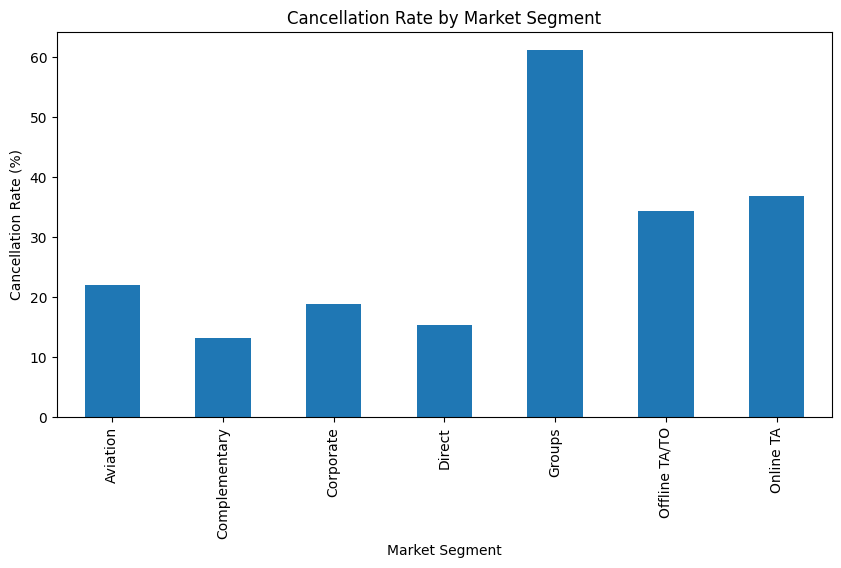

In [16]:
segment_cancel = df.groupby('market_segment')['is_canceled'].mean()*100

plt.figure(figsize=(10,5))
segment_cancel.plot(kind='bar')
plt.title('Cancellation Rate by Market Segment')
plt.xlabel('Market Segment')
plt.ylabel('Cancellation Rate (%)')

**Observations**
- From the above chart, it is cleared that the **Groups** market segment have the highest rate of cancellation than any other groups.

6. Checking The Relationship Between The Cancellation and Deposit Type.

In [22]:
pd.crosstab(df['deposit_type'], df['is_canceled'])

is_canceled,0,1
deposit_type,,
No Deposit,74947,29692
Non Refund,93,14494
Refundable,126,36


Text(0, 0.5, 'Cancellation Rate (%)')

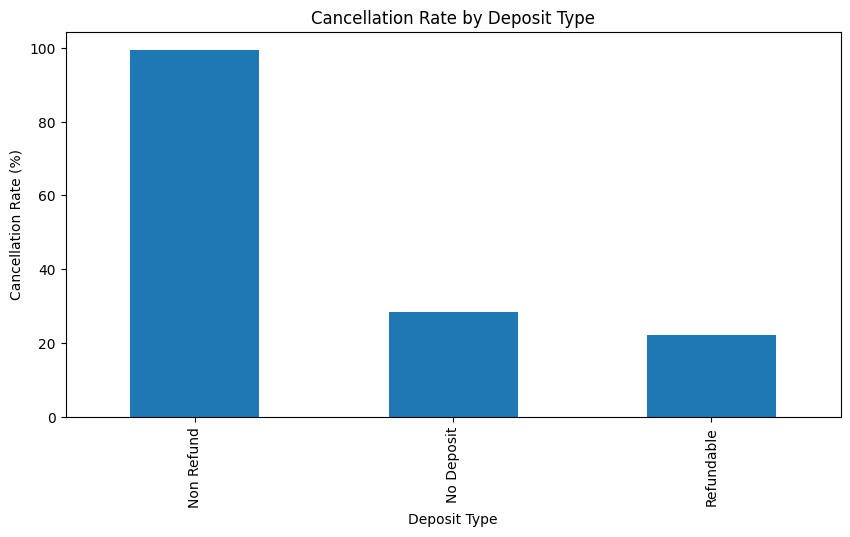

In [20]:
deposit_cancel = df.groupby('deposit_type')['is_canceled'].mean()*100

plt.figure(figsize=(10,5))
deposit_cancel.sort_values(ascending=False).plot(kind='bar')
plt.title('Cancellation Rate by Deposit Type')
plt.xlabel('Deposit Type')
plt.ylabel('Cancellation Rate (%)')

**Observations**
- The highest cancellation rate was observed for bookings with a **Non-Refundable deposit**, indicating a strong relationship between deposit policy and cancellation behavior.

7. Checking The Relationship with the Lead Time & Cancellation Rate

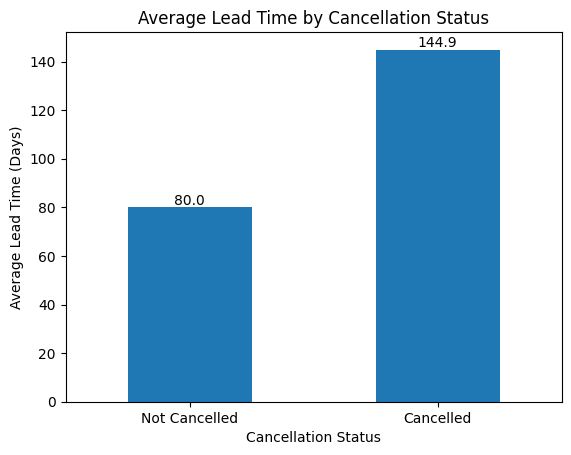

In [23]:
lead_time_avg = df.groupby('is_canceled')['lead_time'].mean()

ax = lead_time_avg.plot(kind='bar')

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f')

plt.title('Average Lead Time by Cancellation Status')
plt.xlabel('Cancellation Status')
plt.ylabel('Average Lead Time (Days)')
plt.xticks([0,1], ['Not Cancelled', 'Cancelled'], rotation=0)

plt.show()

**Observations**
- Customers who cancelled their bookings tended to make reservations much earlier than those who completed their stay, suggesting that bookings made far in advance are more likely to be cancelled due to changes in travel plans.

8. Checking The Relationship between Previous Cancellations and Cancellation Rate

In [24]:
df['previous_cancellations'].value_counts().head(10)

,count
previous_cancellations,
0,112904
1,6051
2,116
3,65
24,48
11,35
4,31
26,26
25,25


**Observations**
- As the data is heavily skewed, we cannot just use it directly for plotting. So we need to create groups for it.

In [25]:
df['has_previous_cancellation'] = np.where(
    df['previous_cancellations'] > 0,
    'Yes',
    'No'
)

Plotting The Has_previous_cancellation with the cancellation rate

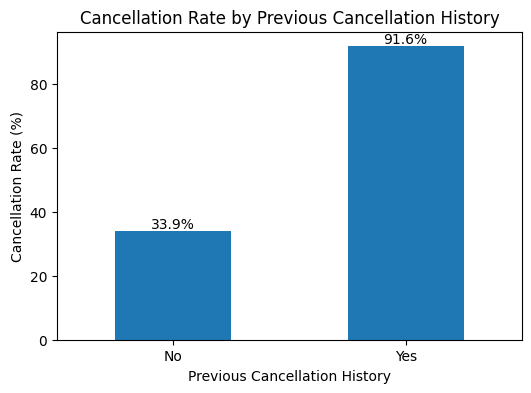

In [27]:
prev_cancel = df.groupby('has_previous_cancellation')['is_canceled'].mean() * 100
plt.figure(figsize=(6,4))

ax = prev_cancel.plot(kind='bar')

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%')

plt.title('Cancellation Rate by Previous Cancellation History')
plt.xlabel('Previous Cancellation History')
plt.ylabel('Cancellation Rate (%)')
plt.xticks(rotation=0)

plt.show()

**Observations**
- From the above it is clear that the customers with a history of previous cancellations were significantly more likely to cancel again.
- Customers who have cancelled in the past are high-risk customers.
These customers may require additional confirmation, reminders, or retention offers.

9. Checking The Relationship Between Previous Booking Not Cancel with the cancellation Rate

In [28]:
df['previous_bookings_not_canceled'].value_counts()

,count
previous_bookings_not_canceled,
0,115768
1,1542
2,580
3,333
4,229
...,...
68,1
69,1
70,1


**Observations**
- This attribute is also heavily skewed so we need to again create the binary feature for understanding.

In [29]:
df['has_previous_successful_booking'] = np.where(
    df['previous_bookings_not_canceled'] > 0,
    'Yes',
    'No'
)

Plotting The Data

In [30]:
prev_success = (
    df.groupby('has_previous_successful_booking')['is_canceled']
      .mean() * 100
)

print(prev_success)

has_previous_successful_booking
No     38.026052
Yes     5.524862
Name: is_canceled, dtype: float64


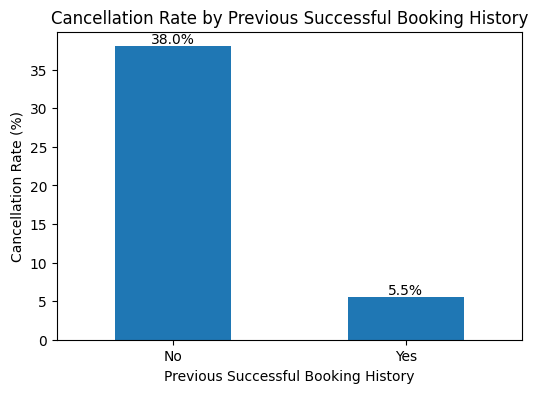

In [31]:
plt.figure(figsize=(6,4))

ax = prev_success.plot(kind='bar')

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%')

plt.title('Cancellation Rate by Previous Successful Booking History')
plt.xlabel('Previous Successful Booking History')
plt.ylabel('Cancellation Rate (%)')
plt.xticks(rotation=0)

plt.show()

**Observations**
- From the above it is clear that the customer with a history of successful bookings were far less likely to cancel their reservations.

10. Checking The Monthly Cancellation Rate

In [34]:
df['arrival_date_month'].unique()

array(['July', 'August', 'September', 'October', 'November', 'December',
       'January', 'February', 'March', 'April', 'May', 'June'],
      dtype=object)

In [32]:
month_order = [
    'January', 'February', 'March', 'April',
    'May', 'June', 'July', 'August',
    'September', 'October', 'November', 'December'
]

monthly_cancel = (
    df.groupby('arrival_date_month')['is_canceled']
      .mean() * 100
)

monthly_cancel = monthly_cancel.reindex(month_order)

Plotting the Data

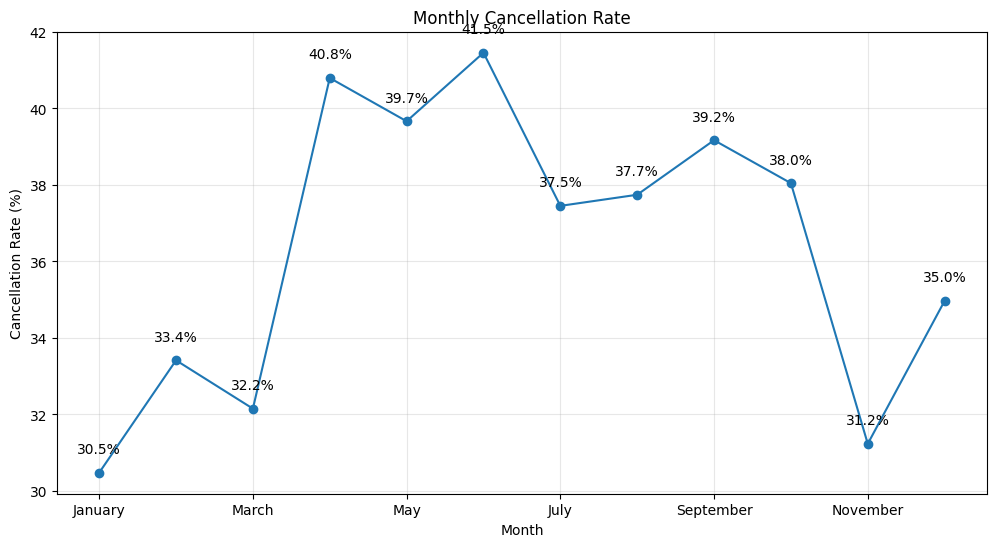

In [36]:
plt.figure(figsize=(12, 6))

ax = monthly_cancel.plot(
    kind='line',
    marker='o'
)

for i, value in enumerate(monthly_cancel):
    plt.text(i, value + 0.5, f'{value:.1f}%', ha='center')

plt.title('Monthly Cancellation Rate')
plt.xlabel('Month')
plt.ylabel('Cancellation Rate (%)')
plt.grid(True, alpha=0.3)

plt.show()

**Observations**
- From the above chart it is cleared that the, **booking cancellations** tend to **increase during the mid-year months**, with the highest cancellation rate recorded in **June (41.5%)**.
- In contrast, the **beginning** of the year **experiences fewer cancellations**, suggesting a seasonal influence on customer booking behavior.

11. Checking for the ADR with cancellation rate

In [37]:
df['adr'].describe()

,adr
count,119388.000000
mean,101.832576
std,50.534962
min,-6.380000
25%,69.290000
50%,94.590000
75%,126.000000
max,5400.000000


**Observations**
- ADR shows the negative minimum value so it is not possible in real time. We should to take care of this.

Checking for negative values in ADR

In [38]:
(df['adr'] < 0).sum()

np.int64(1)

**Observations**
- There's only one negative value which we can easily remove without affecting the whole dataset.

In [39]:
df =  df[df['adr'] >= 0]

Checking for Outliers in ADR

In [40]:
df['adr'].sort_values(ascending=False).head(10)

,adr
48515,5400.00
111403,510.00
15083,508.00
103912,451.50
13142,450.00
13391,437.00
39155,426.25
39568,402.00
39118,397.38
39517,392.00


In [41]:
df.loc[48515]

,48515
hotel,City Hotel
is_canceled,1
lead_time,35
arrival_date_year,2016
arrival_date_month,March
arrival_date_week_number,13
arrival_date_day_of_month,25
stays_in_weekend_nights,0
stays_in_week_nights,1
adults,2


**Observation**
- One booking record had an ADR value of 5400, which was substantially higher than all other observations and was treated as an outlier. The record was removed to prevent distortion of pricing-related analyses and visualizations.

Removing The Outlier

In [42]:
df = df[df['adr'] < 1000]

Plotting The ADR and Cancellation Rate

In [43]:
adr_avg = df.groupby('is_canceled')['adr'].mean()
print(adr_avg)

is_canceled
0     99.989108
1    104.848662
Name: adr, dtype: float64


**Observations**
- Customers who cancelled their bookings had slightly higher room rates on average, but the difference was relatively small, indicating that pricing alone may not be a major factor driving cancellations

12. Plotting The Montly Average ADR.

In [44]:
monthly_adr = (
    df.groupby('arrival_date_month')['adr']
      .mean()
      .reindex(month_order)
)

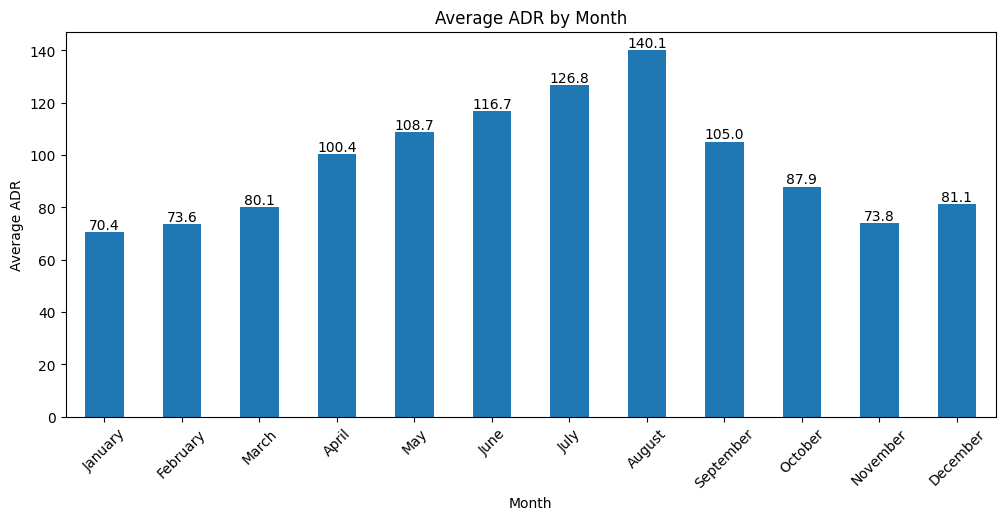

In [46]:
plt.figure(figsize=(12,5))

ax = monthly_adr.plot(kind='bar')

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f')

plt.title('Average ADR by Month')
plt.xlabel('Month')
plt.ylabel('Average ADR')
plt.xticks(rotation=45)

plt.show()

**Observations**
- From the above chart, it is clear that the average room rate shows a clear seasonal pattern, rising steadily from the beginning of the year and peaking in August.
- This indicates that hotels increase prices during high-demand periods and reduce them during off-peak seasons.

13. Plotting The ADR by The Hotel Type

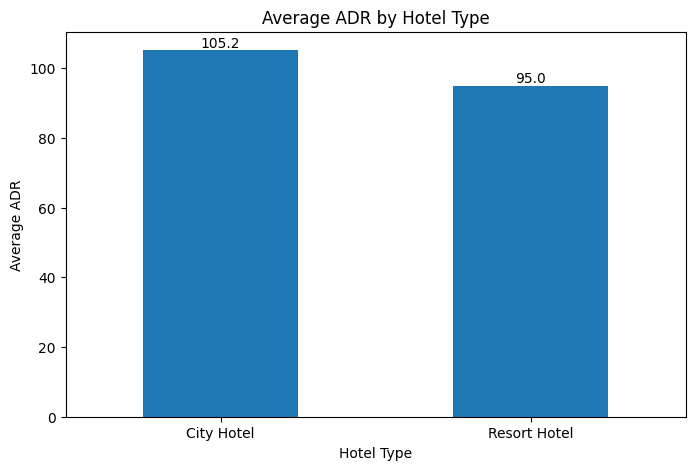

In [48]:

hotel_adr = df.groupby('hotel')['adr'].mean()


plt.figure(figsize=(8,5))

ax = hotel_adr.plot(kind='bar')

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f')

plt.title('Average ADR by Hotel Type')
plt.xlabel('Hotel Type')
plt.ylabel('Average ADR')
plt.xticks(rotation=0)

plt.show()

**Observations**
- From the above it is clear that, **City Hotels** showed a **higher average ADR** than **Resort Hotels**, suggesting greater demand and pricing opportunities in urban locations

14. Plotting The ADR with Reservation Status By Hotel Type

In [57]:
resort_hotel = df[df['hotel'] == 'Resort Hotel']
city_hotel = df[df['hotel'] == 'City Hotel']

In [58]:
resort_hotel = resort_hotel.groupby('reservation_status_date')['adr'].mean()
city_hotel = city_hotel.groupby('reservation_status_date')['adr'].mean()

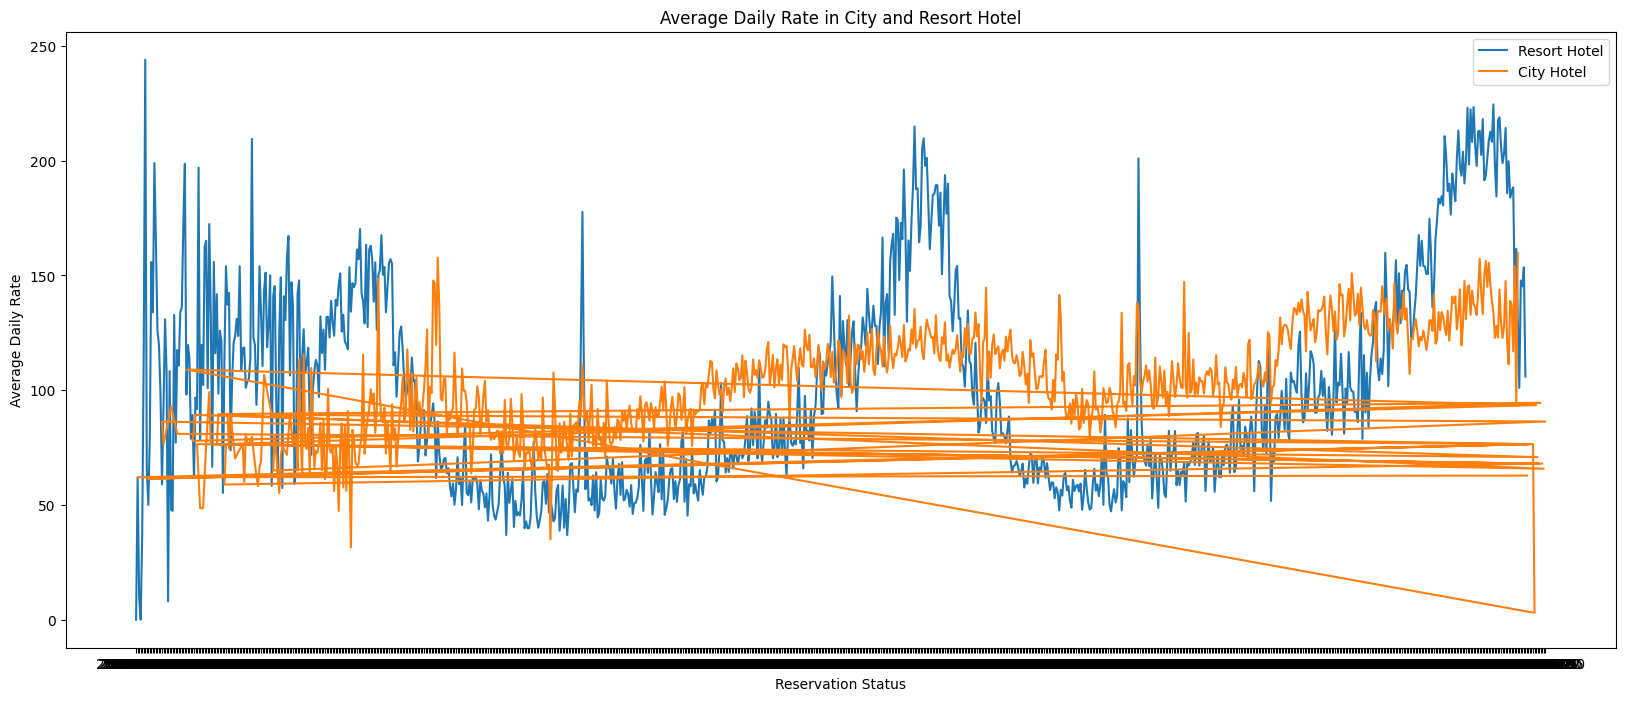

In [63]:

plt.figure(figsize=(20,8))

plt.title("Average Daily Rate in City and Resort Hotel")

plt.plot(resort_hotel.index, resort_hotel.values, label='Resort Hotel')
plt.plot(city_hotel.index, city_hotel.values, label='City Hotel')

plt.xlabel('Reservation Status')
plt.ylabel('Average Daily Rate')
plt.legend()

plt.show()